## Did the Education Program Improve Pupil Test Scores?

# Difference-in-Differences Analysis

## Objective

Estimate the impact of the education support program on pupil test scores using a Difference-in-Differences (DiD) approach.

The DiD estimator compares changes in outcomes over time between treatment and comparison groups.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf

pd.set_option("display.max_columns", None)

In [3]:
# Load the dataset
df = pd.read_csv("../data/synthetic_education_data.csv")
df.head()

,student_id,class_level,gender,treatment,attendance_rate,study_hours,post,time,test_score
0,1,P5,Girl,1,92.3,6.6,0,baseline,70.6
1,2,P6,Boy,1,89.8,3.7,0,baseline,76.9
2,3,P5,Girl,1,95.8,10.9,0,baseline,85.0
3,4,P5,Boy,0,81.2,6.3,0,baseline,68.4
4,5,P5,Boy,0,89.4,6.2,0,baseline,68.7


## Average Scores by Group and Time

In [4]:
df.groupby(
    ["time", "treatment"]
)["test_score"].mean().round(2)

time      treatment
baseline  0            72.47
          1            72.60
endline   0            76.62
          1            83.97
Name: test_score, dtype: float64

In [ ]:
summary = (
    df.groupby(
        ["time", "treatment"]
    )["test_score"]
    .mean()
    .round(2)
    .reset_index()
)

summary

,time,treatment,test_score
0,baseline,0,72.47
1,baseline,1,72.60
2,endline,0,76.62
3,endline,1,83.97


## First DiD Graph

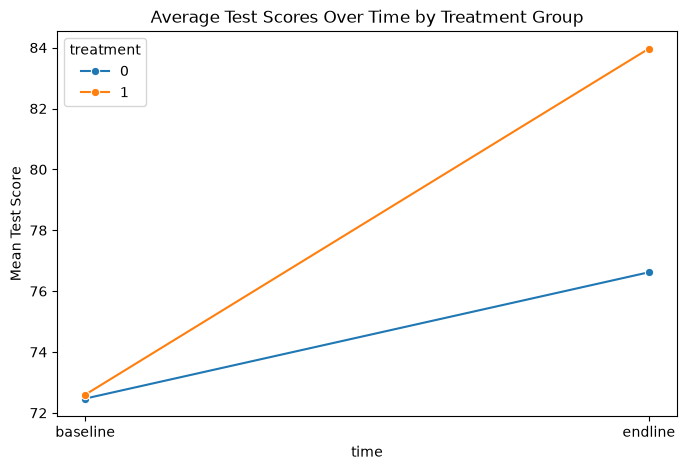

In [6]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=summary,
    x="time",
    y="test_score",
    hue="treatment",
    marker="o"
)

plt.title("Average Test Scores Over Time by Treatment Group")
plt.ylabel("Mean Test Score")

plt.savefig("../outputs/figures/test_score_over_time.png",
            dpi=300,
            bbox_inches="tight"
            )

plt.show()

## The DiD Model

In [7]:
model = smf.ols(
    "test_score ~ treatment * post",
    data=df
).fit()

In [8]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             test_score   R-squared:                       0.400
Model:                            OLS   Adj. R-squared:                  0.396
Method:                 Least Squares   F-statistic:                     105.9
Date:                Tue, 21 Jul 2026   Prob (F-statistic):           1.58e-52
Time:                        14:55:53   Log-Likelihood:                -1529.2
No. Observations:                 480   AIC:                             3066.
Df Residuals:                     476   BIC:                             3083.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         72.4703      0.558    129.

In [11]:
results_table = pd.DataFrame({
    "Coefficient": model.params,
    "Std_Error": model.bse,
    "t_stat": model.tvalues,
    "p_value": model.pvalues
})

results_table.to_csv(
    "../outputs/tables/did_regression_results.csv"
)

results_table

,Coefficient,Std_Error,t_stat,p_value
Intercept,72.470270,0.557785,129.925135,0.000000e+00
treatment,0.130505,0.760812,0.171534,8.638770e-01
post,4.149550,0.788827,5.260406,2.176898e-07
treatment:post,7.224094,1.075951,6.714148,5.401361e-11


In [9]:
# Extract the coefficients and confidence intervals

impact = model.params["treatment:post"]

print(
    f"Estimated Impact of the Program: {impact:.2f} points"
    )

Estimated Impact of the Program: 7.22 points


In [10]:
# Exporting the results of the model.

results = pd.DataFrame({
    "method": ["Difference-in-Differences"],
    "impact": [impact]
})

results.to_csv("../outputs/tables/impact_estimate.csv", index=False)

results

,method,impact
0,Difference-in-Differences,7.224094


# Interpretation of DiD Results

The Difference-in-Differences (DiD) analysis estimates the causal effect of the education support program on pupil test scores.

The interaction term between treatment status and the post-intervention period is positive and statistically significant:

**DiD estimate = 7.22 points (p < 0.001).**

This suggests that pupils who participated in the education support program improved their test scores by approximately **7.22 points more** than pupils in the comparison group between baseline and endline.

The coefficient on `post` (4.15 points) indicates that test scores increased over time for all pupils, regardless of program participation. However, the additional improvement observed among program participants was substantially larger.

These findings provide evidence that the education support program contributed positively to learning outcomes in this hypothetical evaluation.

### Key Result

| Indicator | Estimate |
|------------|-----------:|
| Program Impact (DiD) | 7.22 points |
| 95% Confidence Interval | 5.11 to 9.34 |
| p-value | < 0.001 |

### Important Note

Because the dataset is synthetic and was created for demonstration purposes, the estimated effects should be interpreted as illustrative rather than as evidence from a real intervention.

### Evaluation Takeaway

Using a Difference-in-Differences approach, the program was associated with an estimated improvement of 7.22 test-score points relative to the comparison group. The effect is statistically significant and suggests that program participants experienced greater learning gains over the intervention period.